In [26]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
%matplotlib widget
import matplotlib.pyplot as plt
plt.ioff() # Disable interactive mode; prevent automatic plot updates
import numpy as np
from pathlib import Path

from statsmodels.tsa.stattools import acf

u = unit(coerce_to_integer=True)


# Settings

In [42]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.12 * u.us,
    pulse_amplitude=0.475,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=252.25,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=10550 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "zg"
)

cfg = qnmr.cfg_from_settings(settings)

# Zero-go

This runs a simple free induction decay (FID) experiment using the qeg_nmr_qua package. The experiment applies a single π/2 pulse to the nuclear spin system and measures the resulting FID signal.

This reproduces the "zero-go" function often used in Brucker systems.

2026-03-17 16:30:40,863 - qm - INFO     - Performing health check
2026-03-17 16:30:40,867 - qm - INFO     - Cluster healthcheck completed successfully.
2026-03-17 16:30:41,179 - qm - INFO     - Clearing queue
2026-03-17 16:30:41,185 - qm - INFO     - Adding program to queue.


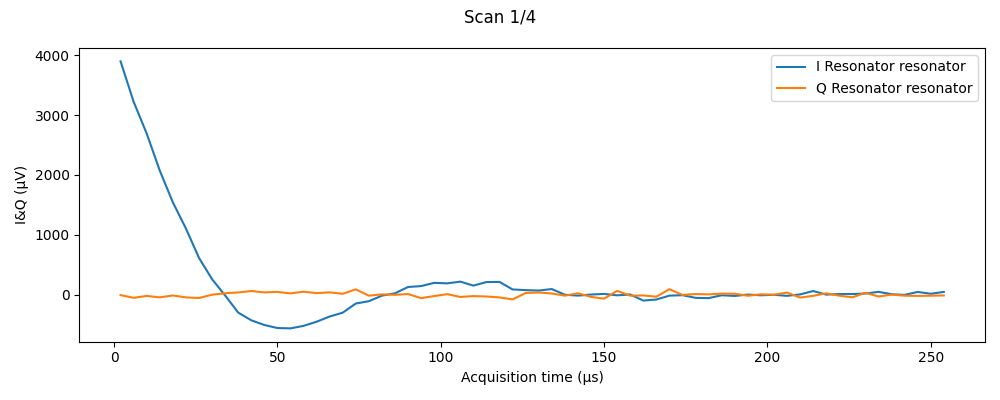

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 12.30s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 12.70s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 13.13s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\zg\experiment_0076


In [43]:
# write an experiment which measures a basic FID signal
zg_expt = qnmr.Experiment1D(config=cfg, settings=settings,)
fc_elements = (settings.res_key, settings.helper_key)
zg_expt.add_frame_change(angle=-4.0, elements=fc_elements)
zg_expt.add_pulse(element=settings.res_key)

zg_expt.execute_experiment()
# zg_expt.remove_initial_delay()
# zg_expt.simulate_experiment()

Increment phase reference by -0.38 degrees to 251.87


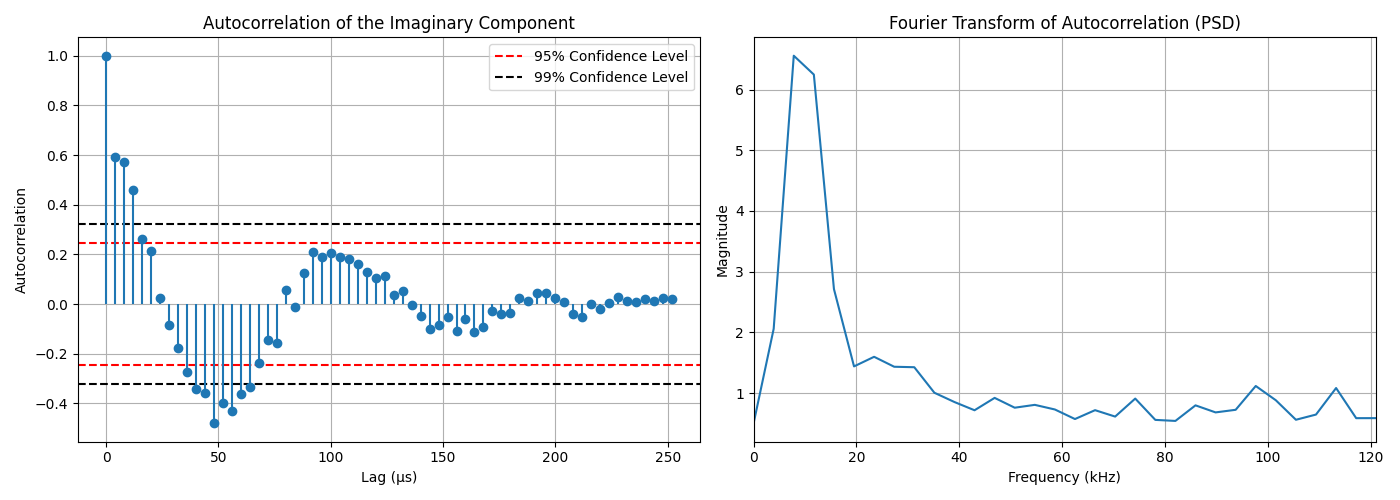

In [44]:
# fit the data
data_dict = zg_expt.save_data_dict
re = np.array(data_dict["I_data"]) * 1e6
im = np.array(data_dict["Q_data"]) * 1e6
ph_ref = np.arctan2(im[0], re[0]) * (180 / np.pi)
times = np.arange(settings.readout_start, settings.readout_end, settings.dwell_time) / u.us # convert to us for plotting

print(f"Increment phase reference by {ph_ref:.2f} degrees to {(settings.rotation_angle+ph_ref):.2f}" )

# --- Autocorrelation ---
autocorr = acf(im, nlags=len(im)-1, fft=True)

# --- Fourier transform of autocorrelation ---
fft_vals = np.fft.fft(autocorr)
dt = settings.dwell_time
freqs = np.fft.fftfreq(len(autocorr), d=dt / u.ms) # convert to kHz (1/ms)
fft_vals_shifted = np.fft.fftshift(fft_vals) # Shift zero frequency to center
freqs_shifted = np.fft.fftshift(freqs)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Confidence bounds
confidence_95 = 1.96 / np.sqrt(len(im))
confidence_99 = 2.58 / np.sqrt(len(im))

# Autocorrelation plot
axs[0].axhline(y=confidence_95, color='red', linestyle='--', label='95% Confidence Level')
axs[0].axhline(y=-confidence_95, color='red', linestyle='--')
axs[0].axhline(y=confidence_99, color='black', linestyle='--', label='99% Confidence Level')
axs[0].axhline(y=-confidence_99, color='black', linestyle='--')

axs[0].stem(times[:len(autocorr)], autocorr, basefmt=" ", markerfmt="o", linefmt="-")
axs[0].set_title("Autocorrelation of the Imaginary Component")
axs[0].set_xlabel("Lag (µs)")
axs[0].set_ylabel("Autocorrelation")
axs[0].legend()
axs[0].grid()

# Fourier transform plot (Power Spectral Density)
axs[1].plot(freqs_shifted, np.abs(fft_vals_shifted))
axs[1].set_title("Fourier Transform of Autocorrelation (PSD)")
axs[1].set_xlim(0, np.max(freqs_shifted))
axs[1].set_xlabel("Frequency (kHz)")
axs[1].set_ylabel("Magnitude")
axs[1].grid()

plt.tight_layout()
plt.show()